# **Projeto Final do Módulo Análise Exploratória de Dados**
Felipe Albanez de Oliveira  
## **Dataset**
vendas_supermercado_com_cliente.csv

## **Objetivo**
Responder as perguntas listadas abaixo combinando **Estatística Descritiva** e **Estatística Inferencial**.  
1. Quais foram as categorias produtos mais vendidos e em quais meses eles tiveram o maior pico de vendas?  

2. Qual foi o impacto das promoções (descontos aplicados) nas vendas?  
   Quais produtos tiveram o maior aumento nas vendas durante as promoções?  

3. Qual a média de vendas diárias por categoria de produto?  

4. Quais produtos apresentam a maior sazonalidade nas vendas (ex.: frutas e vegetais, sorvetes)? Para responder essa pergunta considere a medida de sazonalidade dada pelo coeficiente de variação mensal dos produtos.  
5. Quais as faixas etárias contribuíram mais para as vendas totais? Para responder essa pergunta, crie uma coluna com a faixa etária, considerando: entre 18 e 35 (jovem), entre 36 e 59 (adulto) e acima de 60 anos (idoso). 
6. Qual a distribuição das vendas ao longo dos dias da semana?  

7. Como as vendas mensais se comparam antes e durante a Black Friday?  

08. Qual é o ticket médio (valor médio das vendas) por faixa etária e como ele varia entre diferentes categorias de produto?   

09. Qual é a relação entre a idade dos clientes e o valor total das compras?  

10. Comparando a semana da "Black Friday" com a do Natal, qual semana a empresa teve melhores desempenhos em 
relação à média de vendas? 

---
## 1.   **Diagnóstico Inicial**

### **1.1.  Criação do Dataframe**
Importando as bibliotecas e lendo o arquivo com `read_csv`  
Transformando a coluna `Data` em datetime com `parse_date`

In [1]:
# importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df_vendas = pd.read_csv('vendas_supermercado_com_cliente.csv', parse_dates=['Data'])

### **1.2.   Vizualização do Dataframe**
Métodos `head` e `tail`

In [339]:
# vizualisa as 5 primeiras linhas do dataframe
display(df_vendas.head())
# vizualisa as 5 ultimas linhas do dataframe
display(df_vendas.tail())

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,Mês,Dia da Semana,Faixa Etária,Semana
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.0,164.60,49,2715.61,1,Domingo,Adulto,52
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.0,9.56,29,2280.15,1,Domingo,Jovem,52
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.0,41.90,67,4419.56,1,Domingo,Idoso,52
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.0,30.45,29,3809.17,1,Domingo,Jovem,52
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.0,519.96,24,1013.42,1,Domingo,Jovem,52


,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,Mês,Dia da Semana,Faixa Etária,Semana
20070,2023-12-31,Produtos de higiene para pets,Pet Shop,26.62,15,0.21,315.4470,39,2475.82,12,Domingo,Adulto,52
20071,2023-12-31,Panelas,Utilidades Domésticas,33.00,19,0.15,532.9500,25,4766.49,12,Domingo,Jovem,52
20072,2023-12-31,Talheres,Utilidades Domésticas,27.60,12,0.29,235.1520,65,3367.68,12,Domingo,Idoso,52
20073,2023-12-31,Copos,Utilidades Domésticas,15.35,13,0.25,149.6625,42,3823.50,12,Domingo,Adulto,52
20074,2023-12-31,"Produtos descartáveis (pratos, copos, talheres)",Utilidades Domésticas,32.06,6,0.11,171.2004,59,3303.47,12,Domingo,Adulto,52


### **1.3.  Conhecendo o Dataframe**
Métodos `shape` e `info`

In [4]:
# informar o número de linhas e colunas
print('Shape:', df_vendas.shape)

Shape: (20075, 9)


In [5]:
# Informações do DataFrame, incluindo o índice dtype e colunas, valores não-NA e uso de memória
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Data         20075 non-null  datetime64[ns]
 1   Produto      20075 non-null  object        
 2   Categoria    20075 non-null  object        
 3   Preço        20075 non-null  float64       
 4   Quantidade   20075 non-null  int64         
 5   Desconto     20075 non-null  float64       
 6   Total_Venda  20075 non-null  float64       
 7   Idade        20075 non-null  int64         
 8   Renda        20075 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 1.4+ MB


### **1.4.  Estatísticas Descritivas**
Método `describle` e utilização de `np.number` e `object`

In [13]:
# distribuição dos números
df_vendas.describe().round(2)

,Data,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
count,20075,20075.00,20075.00,20075.00,20075.00,20075.00,20075.00
mean,2023-07-02 00:00:00,25.58,10.01,0.04,245.90,45.99,2999.03
min,2023-01-01 00:00:00,1.00,1.00,0.00,0.91,18.00,1000.38
25%,2023-04-02 00:00:00,13.26,5.00,0.00,75.60,32.00,1993.62
50%,2023-07-02 00:00:00,25.66,10.00,0.00,186.32,46.00,2998.83
75%,2023-10-01 00:00:00,37.77,15.00,0.00,370.04,60.00,4007.68
max,2023-12-31 00:00:00,49.99,19.00,0.50,949.05,74.00,4999.76
std,NaN,14.12,5.49,0.09,207.77,16.48,1159.72


In [14]:
# incluindo apenas colunas numéricas
df_vendas.describe(include=[np.number]).round(2)


,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
count,20075.00,20075.00,20075.00,20075.00,20075.00,20075.00
mean,25.58,10.01,0.04,245.90,45.99,2999.03
std,14.12,5.49,0.09,207.77,16.48,1159.72
min,1.00,1.00,0.00,0.91,18.00,1000.38
25%,13.26,5.00,0.00,75.60,32.00,1993.62
50%,25.66,10.00,0.00,186.32,46.00,2998.83
75%,37.77,15.00,0.00,370.04,60.00,4007.68
max,49.99,19.00,0.50,949.05,74.00,4999.76


In [7]:
# incluindo apenas colunas categóricas
df_vendas.describe(include=[object])

,Produto,Categoria
count,20075,20075
unique,55,9
top,Maçãs,Alimentos Frescos
freq,365,5475


### **1.5.  Verificando inconsistências na Categorização**

Método `value.counts` e `unique`  

> ##### Não foram localizados valores repetidos ou com erro de digitação.  

#### Vizualisação dos nomes de cada categoria

In [52]:
# mostra todas as colunas do dataframe
df_vendas.columns

Index(['Data', 'Produto', 'Categoria', 'Preço', 'Quantidade', 'Desconto',
       'Total_Venda', 'Idade', 'Renda'],
      dtype='object')

#### Frequência para cada coluna categórica: `Produto`, `Categoria`

In [53]:
# contar quantas vezes cada valor único aparece em uma coluna
df_vendas['Categoria'].value_counts(dropna=False)

Categoria
Alimentos Frescos              5475
Produtos de Mercearia          2190
Laticínios e Ovos              1825
Bebidas                        1825
Produtos de Limpeza            1825
Produtos de Higiene Pessoal    1825
Congelados                     1825
Pet Shop                       1825
Utilidades Domésticas          1460
Name: count, dtype: int64

#### Padronização textual (visual) 

In [54]:
# unique: cria uma lista com valores únicos da coluna Produto
# sorted: ordena em ordem alfáberica para facilitar a conferência visual
print(sorted(df_vendas['Produto'].unique()))

['Alface', 'Amaciantes', 'Arroz', 'Atum', 'Azeite', 'Bananas', 'Brinquedos para pets', 'Carne bovina', 'Carne suína', 'Cenouras', 'Cervejas', 'Copos', 'Creme dental', 'Croissants', 'Desodorantes', 'Detergentes', 'Esponjas', 'Farinha', 'Feijão', 'Frango', 'Frango empanado', 'Iogurte', 'Laranjas', 'Leite', 'Limpadores multiuso', 'Macarrão', 'Manteiga', 'Maçãs', 'Ovos', 'Panelas', 'Papel higiênico', 'Petiscos', 'Pizzas congeladas', 'Pratos prontos congelados', 'Produtos de higiene para pets', 'Produtos descartáveis (pratos, copos, talheres)', 'Pão francês', 'Pão integral', 'Queijo', 'Ração para cães', 'Ração para gatos', 'Refrigerantes', 'Sabonetes', 'Sabão em pó', 'Salmão', 'Shampoos', 'Sorvetes', 'Sucos', 'Talheres', 'Tilápia', 'Tomates', 'Vegetais congelados', 'Vinhos', 'Água mineral', 'Óleo']


### **1.6. Verificando valores negativos**
Metódo `select_dtypes` e `include number`  
> ##### Não foram localizados valores negativos.

#### Lista das colunas numéricas

In [ ]:
# seleciona somente as colunas do df com valores numéricos e retorna somente o cabeçalho
df_vendas.select_dtypes(include ='number').head(0)

,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda


#### Conferencia de valores negativos em cada coluna

In [ ]:
# verifica se existe valores negativos na coluna. Caso existir retorna o valor booleano True
# cria um df contendo somente os valores True
df_vendas[df_vendas['Preço'] < 0]

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda


In [45]:
df_vendas[df_vendas['Desconto'] < 0]

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda


In [46]:
df_vendas[df_vendas['Total_Venda'] < 0]

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda


In [47]:
df_vendas[df_vendas['Desconto'] < 0]

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda


In [49]:
df_vendas[df_vendas['Idade'] < 0]

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda


In [50]:
df_vendas[df_vendas['Renda'] < 0]

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda


### **1.7.  Identificando Duplicados**
Método `duplicated`  
> ##### Não foram localizadas linhas duplicadas

#### Identificação de linhas totalmente duplicadas

In [ ]:
# verifica se existe valores duplicados. Caso existir retorna o valor booleano True
# cria um df contendo somente os valores True
df_vendas[df_vendas.duplicated()]

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda


### **1.8.  Localizando faltantes**
Método `isna`
> ##### Não foram localizados faltantes

In [ ]:
# mostra o total de linhas em branco para cada coluna
df_vendas.isna().sum()

Data           0
Produto        0
Categoria      0
Preço          0
Quantidade     0
Desconto       0
Total_Venda    0
Idade          0
Renda          0
dtype: int64

In [58]:
# Mostra todas as linhas da tabela que possuem algum campo em branco
df_vendas[df_vendas.isna().any(axis=1)]

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda


---
## **2. Criação de Colunas**

Para respondermos algumas perguntas, é necessário criarmos novas colunas para utilizarmos funções como 'Groupby'.

### Coluna Mês

In [247]:
# df_vendas['Mês']: cria uma coluna no dataframe chama Mês
# dt.month: extrai da coluna data apenas o número do mês
df_vendas['Mês'] = df_vendas['Data'].dt.month
display(df_vendas.head(1))

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,Mês,Dia da Semana,Faixa Etária,Semana
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.0,164.6,49,2715.61,1,Domingo,Adulto,52


### Coluna Dia da Semana

In [ ]:
df_vendas['Dia da Semana'] = df_vendas['Data'].dt.day_name(locale = 'pt_BR')
display(df_vendas.head(1))

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,Mês,Dia da Semana
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.0,164.6,49,2715.61,1,Domingo


### Coluna Faixa Etária
Método `pd.cut`

In [96]:
# lista de números indicando onde cada faixa começa e termina
# Por padrão, o pd.cut() inclui o número do lado direito e exclui o do lado esquerdo (vazio, inclui].
# Por isso, no código acima, usamos o limite inicial como 17, assim o Pandas garante que quem tem 18 anos 
# cravados entrará perfeitamente na categoria 'jovem'.
idade_limite = [17, 35, 59, 150]

# lista com os nomes textuais de cada categoria
categoria = ['Jovem', 'Adulto', 'Idoso']

# cria nova coluna
df_vendas['Faixa Etária'] = pd.cut(df_vendas['Idade'], bins = idade_limite, labels = categoria)

display(df_vendas.head(1))


,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,Mês,Dia da Semana,Faixa Etária
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.0,164.6,49,2715.61,1,Domingo,Adulto


In [97]:
# confirmaçao se a categorização deu certo
display(df_vendas.loc[(df_vendas['Idade'] == 18), ['Idade', 'Faixa Etária']].head(1))

,Idade,Faixa Etária
110,18,Jovem


### Coluna Semana
Método `dt.isocalendar().week`

In [239]:
df_vendas['Semana'] = df_vendas['Data'].dt.isocalendar().week
display(df_vendas.head(2))

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,Mês,Dia da Semana,Faixa Etária,Semana
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.0,164.60,49,2715.61,1,Domingo,Adulto,52
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.0,9.56,29,2280.15,1,Domingo,Jovem,52


---
## **Análise Descritiva**

#### Medidas de tendência central (média, mediana e moda)
**Variáveis numéricas:** preço, quantidade vendida, desconto, valor total da venda, idade e renda.


In [ ]:
df_vendas['Idade', 'Renda'].describe()

#### Medidas de tendência central (média, mediana e moda) e de dispersão (desvio-padrão, variância, amplitude, coeficiente de variação) para as variáveis numéricas: preço, quantidade vendida, desconto, valor total da venda, idade e renda.

---
## **Análise Exploratória**

#### 1. Quais foram as categorias produtos mais vendidos e em quais meses eles tiveram o maior pico de vendas?
> #### Os números mostram que a gategoria Alimentos Frescos corresponde a quase 28% do total de vendas da loja.

#### Categorias com mais vendas e seus valores

In [273]:
# cria uma series, faz o agrupamento por categoria, soma o total de vendas por categoria, arredonda o valor e ordena do maior para o menor
vendas_gategorias = df_vendas.groupby(['Categoria'])['Total_Venda'].sum().round(2).sort_values(ascending=False).reset_index()
vendas_gategorias

,Categoria,Total_Venda
0,Alimentos Frescos,1365309.46
1,Produtos de Mercearia,529653.65
2,Laticínios e Ovos,459960.47
3,Bebidas,454394.16
4,Produtos de Limpeza,447545.86
5,Pet Shop,440331.56
6,Produtos de Higiene Pessoal,440039.48
7,Congelados,439720.13
8,Utilidades Domésticas,359522.58


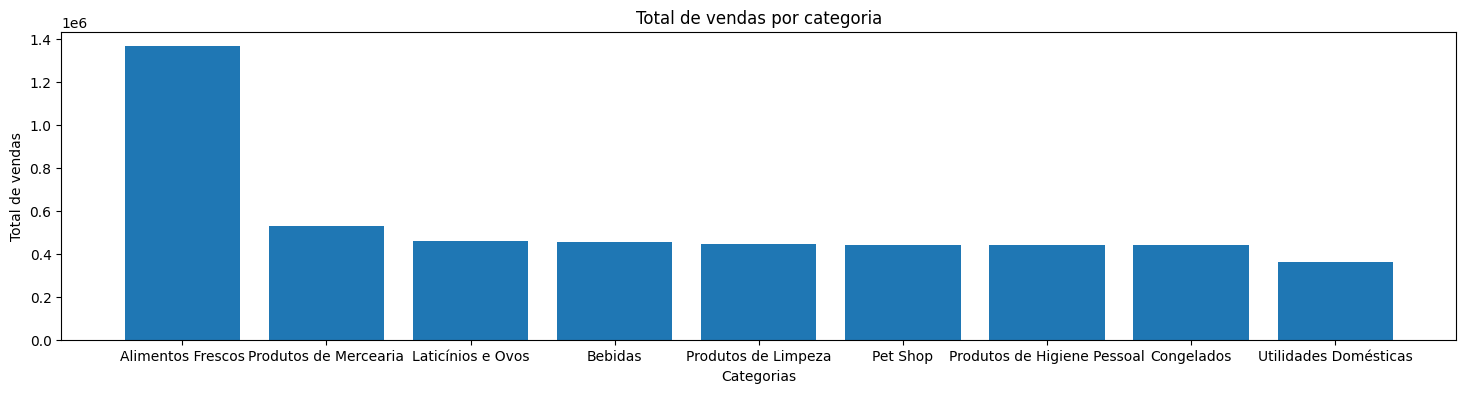

In [287]:
fig, ax = plt.subplots(figsize = (18,4))

ax.bar(vendas_gategorias['Categoria'], vendas_gategorias['Total_Venda'])
ax.set_title('Total de vendas por categoria')
ax.set_xlabel('Categorias')
ax.set_ylabel('Total de vendas')
plt.show()

#### Tabela de Frequência Percentual

In [356]:
# series agrupada por categora e a soma das vendas
vd_cat = df_vendas.groupby(['Categoria']) ['Total_Venda'].sum().round(2)
# series anterior dividida pelo total de vendas, multiplicada por 100, arredonda e transforma os dados em str incluindo o %
vd_cat_porcentagem = (vd_cat/df_vendas['Total_Venda'].sum()).mul(100).round(2).astype(str) + " %"
vd_cat_porcentagem

Categoria
Alimentos Frescos              27.66 %
Bebidas                          9.2 %
Congelados                      8.91 %
Laticínios e Ovos               9.32 %
Pet Shop                        8.92 %
Produtos de Higiene Pessoal     8.91 %
Produtos de Limpeza             9.07 %
Produtos de Mercearia          10.73 %
Utilidades Domésticas           7.28 %
Name: Total_Venda, dtype: object

#### Mês que houve o maior número de vendas para cada categoria

In [288]:
# cria um df, agrupa por categoria e mês, soma o total de venda de categoria por mês, faz o arredondamento e transforma o df com colunas normais
vendas_cat_mes = df_vendas.groupby(['Categoria', 'Mês'])['Total_Venda'].sum().round(2).reset_index()
# cria uma series, ordena a coluna Total_Venda do anterior  do maior para o menor, remove as valores duplicados da coluna Categorias
melhor_mes = vendas_cat_mes.sort_values('Total_Venda',ascending=False).drop_duplicates(subset=['Categoria'])
# ao remover os valores duplicados, mantem os primeiros valores (maior, pois antes foram ordenados)
melhor_mes

,Categoria,Mês,Total_Venda
2,Alimentos Frescos,3,129103.45
92,Produtos de Mercearia,9,48192.29
12,Bebidas,1,47415.71
45,Laticínios e Ovos,10,43440.80
78,Produtos de Limpeza,7,42358.75
66,Produtos de Higiene Pessoal,7,42213.35
48,Pet Shop,1,40577.29
33,Congelados,10,40418.34
102,Utilidades Domésticas,7,36674.81


#### 2. Qual foi o impacto das promoções (descontos aplicados) nas vendas? Quais produtos tiveram o maior aumento nas vendas durante as promoções? 

> #### Não foi identificado aumento expressivo no número de vendas quando é um desconto é aplicado.

In [ ]:
# series com os produtos sem desconto aplicado
vd_sem_desconto = df_vendas.loc[df_vendas['Desconto'] == 0, ['Produto', 'Quantidade', 'Total_Venda']]
# series da média da quantidade de produtos vendidos
sem_desconto = vd_sem_desconto.groupby(['Produto']) ['Quantidade'].mean().round()

In [381]:
vd_com_desconto = df_vendas.loc[df_vendas['Desconto'] > 0, ['Produto', 'Quantidade', 'Total_Venda']]
com_desconto = vd_com_desconto.groupby(['Produto']) ['Quantidade'].mean().round()

In [384]:
resultado = (com_desconto - sem_desconto).sort_values(ascending=False)
resultado

Produto
Maçãs                                              1.0
Cervejas                                           1.0
Leite                                              1.0
Papel higiênico                                    1.0
Frango                                             1.0
Farinha                                            1.0
Ração para cães                                    1.0
Bananas                                            1.0
Talheres                                           1.0
Azeite                                             1.0
Shampoos                                           0.0
Ovos                                               0.0
Tilápia                                            0.0
Panelas                                            0.0
Pizzas congeladas                                  0.0
Pratos prontos congelados                          0.0
Produtos de higiene para pets                      0.0
Salmão                                             0.0
Pã

#### 3. Qual a média de vendas diárias por categoria de produto?   
 > Os números mostram que Alimentos Frescos é a gategoria que possui o maior volume de vendas diária.

#### Média diária de vendas por categoria

In [358]:
# cria um df agrupado por categoria e data, faz a soma das vendas para cada dia do ano, arredonda o valor e transforma a series em df
vd_cat_diaria = df_vendas.groupby(['Categoria', 'Data'])['Total_Venda'].sum().round(2).reset_index()
# cria uma series agrupada por Categoria do df anterior, faz a média da coluna Total_Venda e arredonda o valor
md_cat_diaria = vd_cat_diaria.groupby(['Categoria'])['Total_Venda'].mean().round(2).reset_index()
# retorna uma series com a média diária de vendas de cada categoria
md_cat_diaria

,Categoria,Total_Venda
0,Alimentos Frescos,3740.57
1,Bebidas,1244.92
2,Congelados,1204.71
3,Laticínios e Ovos,1260.17
4,Pet Shop,1206.39
5,Produtos de Higiene Pessoal,1205.59
6,Produtos de Limpeza,1226.15
7,Produtos de Mercearia,1451.11
8,Utilidades Domésticas,984.99


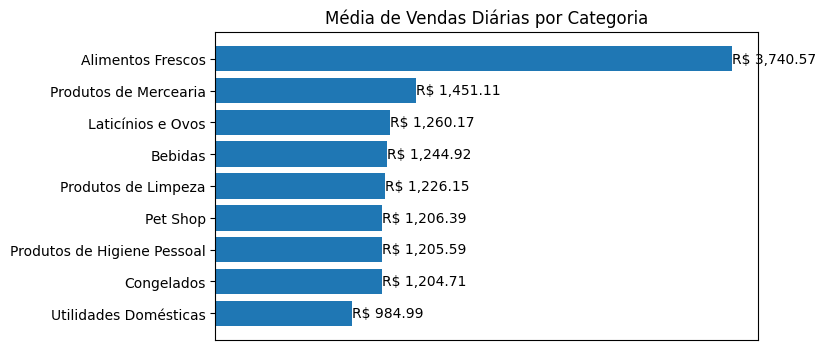

In [338]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # Importação essencial para corrigir o eixo

fig, ax = plt.subplots(figsize=(7, 4))
# Ordena do maior para o menor
md_cat_diaria = md_cat_diaria.sort_values('Total_Venda', ascending=True)
barras = ax.barh(md_cat_diaria['Categoria'], md_cat_diaria['Total_Venda'])

# Força o rótulo a mostrar o valor real por extenso
# O ':,.2f' formata com separador de milhar e duas casas decimais
ax.bar_label(barras, fmt='R$ {:,.2f}')

# Títulos
ax.set_title('Média de Vendas Diárias por Categoria')
# Esconde o eixo de baixo já que os valores estão nas barras
ax.xaxis.set_visible(False)

#for borda in ['top', 'right', 'bottom']:
 #   ax.spines[borda].set_visible(False)

#plt.tight_layout()
plt.show()

#### 4. Quais produtos apresentam a maior sazonalidade nas vendas (ex.: frutas e vegetais, sorvetes)? Para responder essa pergunta considere a medida de sazonalidade dada pelo coeficiente de variação mensal dos produtos. 

#### 5. Quais as faixas etárias contribuíram mais para as vendas totais? Para responder essa pergunta, crie uma coluna com a faixa etária, considerando: entre 18 e 35 (jovem), entre 36 e 59 (adulto) e acima de 60 anos (idoso).

#### Valor Total em vendas por faixa etária

In [352]:
vd_faixa_etaria = df_vendas.groupby(['Faixa Etária'],observed=False)['Total_Venda'].sum().round(2).sort_values(ascending=False)
vd_faixa_etaria

Faixa Etária
Adulto    2102041.77
Jovem     1537183.38
Idoso     1297252.20
Name: Total_Venda, dtype: float64

#### Tabela de Frequência Percentual

In [ ]:
# series anterior dividida pelo total de vendas, multiplicada por 100, arredonda e transforma os dados em str incluindo o %
vd_faixa_pct = (vd_faixa_etaria/df_vendas['Total_Venda'].sum()).mul(100).round(2).astype(str) + " %"
vd_faixa_pct

Faixa Etária
Adulto    42.58 %
Jovem     31.14 %
Idoso     26.28 %
Name: Total_Venda, dtype: object

#### 6. Qual a distribuição das vendas ao longo dos dias da semana?  
 


In [ ]:
vendas_semana = df_vendas.groupby(['Dia da Semana'])['Total_Venda'].sum().round(2).reset_index()
vendas_semana

,Dia da Semana,Total_Venda
0,Domingo,722783.68
1,Quarta feira,710052.02
2,Quinta feira,706311.13
3,Segunda feira,695777.31
4,Sexta feira,707290.91
5,Sábado,707984.37
6,Terça feira,686277.94


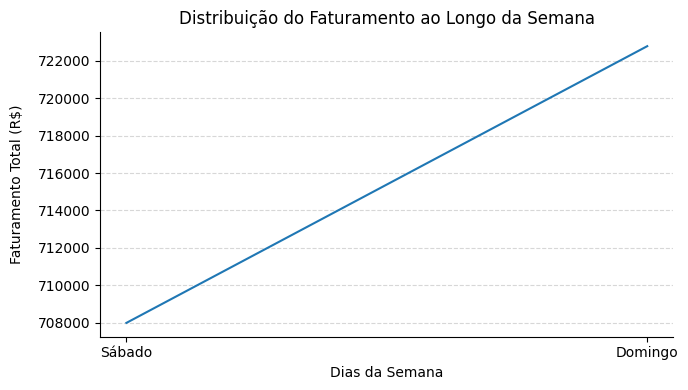

In [ ]:
# força a tabela a seguir a ordem natural dos dias
ordem_dias = ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo']
vendas_semana = vendas_semana.set_index('Dia da Semana').reindex(ordem_dias).reset_index()

# "Imprime" folha em branco
fig, ax = plt.subplots(figsize=(7, 4))

# 4. Desenha o gráfico de linha (ax.plot)
# Passamos os dias no eixo X, o dinheiro no eixo Y, definimos a cor e adicionamos marcadores (bolinhas) nos dias
ax.plot(vendas_semana['Dia da Semana'], vendas_semana['Total_Venda'])
       # color='#2b5c8f', marker='o', linewidth=2.5, markersize=6)

# 5. Adiciona os títulos e rótulos de identificação
ax.set_title('Distribuição de Venda ao Longo da Semana')#, fontsize=12, pad=15, fontweight='bold')
ax.set_xlabel('Dias da Semana')#, fontsize=10, labelpad=10)
ax.set_ylabel('Venda Total')

# 6. Ativa linhas de grade suaves ao fundo para ajudar o leitor a guiar o olhar
ax.grid(True, linestyle='--', alpha=0.5, axis='y')

# 7. Truque Sênior: Remove as bordas desnecessárias da caixa (superior e direita)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 8. Ajusta o espaçamento e exibe o gráfico finalizado
plt.tight_layout()
plt.show()


#### 7. Como as vendas mensais se comparam antes e durante a Black Friday? 

#### 8. Qual é o ticket médio (valor médio das vendas) por faixa etária e como ele varia entre diferentes categorias de produto?

In [226]:
# df agrupado por faixa etária/categoria e calculo da média
faixa_categoria = df_vendas.groupby(['Faixa Etária','Categoria'], observed=False)['Total_Venda'].mean().round(2).reset_index()
# representação da variação utilizando pivot_table
tabela_ticket_medio = faixa_categoria.pivot_table(index='Categoria', columns='Faixa Etária', values='Total_Venda',
                                                  aggfunc='mean', fill_value=0, observed=False).round(2)
tabela_ticket_medio

Faixa Etária,Jovem,Adulto,Idoso
Categoria,,,
Alimentos Frescos,241.41,253.66,251.97
Bebidas,249.46,240.42,261.24
Congelados,234.94,245.67,240.42
Laticínios e Ovos,252.19,249.26,256.35
Pet Shop,237.33,247.80,234.93
Produtos de Higiene Pessoal,237.54,244.52,240.05
Produtos de Limpeza,245.42,249.26,238.87
Produtos de Mercearia,238.58,242.30,245.31
Utilidades Domésticas,246.16,246.39,246.13


#### 09. Qual é a relação entre a idade dos clientes e o valor total das compras?  


In [228]:
correlacao_idade = df_vendas[['Idade', 'Total_Venda']].corr()
correlacao_idade

,Idade,Total_Venda
Idade,1.00000,0.00767
Total_Venda,0.00767,1.00000


#### 10. Comparando a semana da "Black Friday" com a do Natal, qual semana a empresa teve melhores desempenhos em relação à média de vendas? 

##### Média das vendas por semana

In [ ]:
# df agrupado por semana com o resultado da média das vendas de cada semana
md_semana = df_vendas.groupby(['Semana'])['Total_Venda'].mean().round(2).reset_index()
# media das vendas de todas as semanas
md_semana_total = md_semana['Total_Venda'].mean().round(2)
md_semana_total

np.float64(245.97)

##### Média das vendas na semana da Back Friday

> Black Friday de 2023 considerada no dia 24 de novembro

In [258]:
# localizar a semana do dia 24/11/2023
df_vendas.loc[df_vendas['Data'] == '2023-11-24',['Semana']].iloc[0]

Semana    47
Name: 17985, dtype: UInt32

In [261]:
# mascara para encontrar a media da semana 47
md_bf = df_vendas[df_vendas['Semana'] == 47] ['Total_Venda'].mean().round(2)
md_bf

np.float64(198.58)

##### Média das vendas na semana do Natal

In [262]:
df_vendas.loc[df_vendas['Data'] == '2023-12-25',['Semana']].iloc[0]

Semana    52
Name: 19690, dtype: UInt32

In [ ]:
md_natal = df_vendas[df_vendas['Semana'] == 52] ['Total_Venda'].mean().round(2)
md_natal

np.float64(219.75)

In [264]:
print("Média Geral:", md_semana_total)
print("Média Black Friday:", md_bf)
print("Média Natal:", md_natal)

Média Geral: 245.97
Média Black Friday: 198.58
Média Natal: 219.75
